In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

# Download latest version
path = kagglehub.dataset_download("alinaboulsi/digital-marketing-performance-dataset")

print("Path to dataset files:", path)

/kaggle/input/datasets/alinaboulsi/digital-marketing-performance-dataset/README_DATASET.md
/kaggle/input/datasets/alinaboulsi/digital-marketing-performance-dataset/digital_marketing_dataset_30k.csv
/kaggle/input/datasets/alinaboulsi/digital-marketing-performance-dataset/data_dictionary.csv
Path to dataset files: /kaggle/input/datasets/alinaboulsi/digital-marketing-performance-dataset


In [2]:
import duckdb
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/alinaboulsi/digital-marketing-performance-dataset/digital_marketing_dataset_30k.csv')

sql_query = """
SELECT
    platform,
    SUM(COALESCE(clicks, 0))      AS total_clicks,
    SUM(COALESCE(conversions, 0))  AS total_conversions
FROM df
GROUP BY platform
"""

result = duckdb.sql(sql_query).df() 
print('-------------------------------')
print('Conversions∼Binomial(Clicks,theta_meta)')
print('-------------------------------')
print(result)

-------------------------------
Conversions∼Binomial(Clicks,theta_meta)
-------------------------------
         platform  total_clicks  total_conversions
0        Snapchat     3230264.0            21148.0
1            Meta     4439765.0            41978.0
2        LinkedIn      685644.0             5588.0
3          TikTok     3936117.0            28281.0
4  Google Display     1809793.0             9109.0
5   Google Search    11515557.0           216694.0


In [3]:
alpha_prior = 1
beta_prior = 1

meta_clicks = 4439765
meta_conv = 41978

meta_alpha_post = alpha_prior + meta_conv
meta_beta_post = beta_prior + meta_clicks - meta_conv

tiktok_clicks = 3936117
tiktok_conv = 28281

tiktok_alpha_post = alpha_prior + tiktok_conv
tiktok_beta_post = beta_prior + tiktok_clicks - tiktok_conv

print(f'theta_meta ~ beta({meta_alpha_post},{meta_beta_post})')
print(f'theta_tiktok ~ beta({tiktok_alpha_post},{tiktok_beta_post})')

theta_meta ~ beta(41979,4397788)
theta_tiktok ~ beta(28282,3907837)


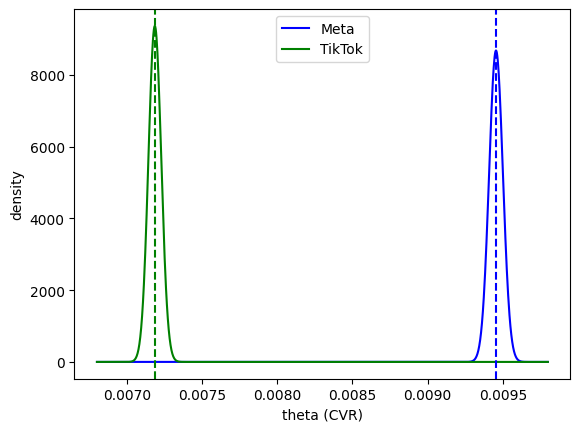

Meta  : mean=0.009455, var=2.110e-09, std=0.000046
TikTok: mean=0.007185, var=1.812e-09, std=0.000043
P(θ_Meta > θ_TikTok​)≈1.0


In [4]:
from scipy.stats import beta

a_meta,   b_meta   = 41979, 4397788
a_tiktok, b_tiktok = 28282, 3907837

x = np.linspace(0.0068, 0.0098, 1000)

y_meta   = beta.pdf(x, a_meta,   b_meta)
y_tiktok = beta.pdf(x, a_tiktok, b_tiktok)

plt.plot(x, y_meta,   label='Meta',   color='blue')
plt.plot(x, y_tiktok, label='TikTok', color='green')

plt.axvline(a_meta/(a_meta+b_meta),     color='blue',  ls='--')
plt.axvline(a_tiktok/(a_tiktok+b_tiktok), color='green', ls='--')

plt.xlabel('theta (CVR)')
plt.ylabel('density')
plt.legend()
plt.show()

# E = a/(a+b)
mean_meta   = a_meta   / (a_meta   + b_meta)
mean_tiktok = a_tiktok / (a_tiktok + b_tiktok)

# Var = a*b / ((a+b)^2 * (a+b+1))
var_meta   = (a_meta * b_meta)     / ((a_meta + b_meta)**2     * (a_meta + b_meta + 1))
var_tiktok = (a_tiktok * b_tiktok) / ((a_tiktok + b_tiktok)**2 * (a_tiktok + b_tiktok + 1))

print(f'Meta  : mean={mean_meta:.6f}, var={var_meta:.3e}, std={var_meta**0.5:.6f}')
print(f'TikTok: mean={mean_tiktok:.6f}, var={var_tiktok:.3e}, std={var_tiktok**0.5:.6f}')
print('P(θ_Meta > θ_TikTok​)≈1.0')

In [5]:
alpha_prior = 1
beta_prior = 1

snapchat_clicks = 3230264
snapchat_conv = 21148

snapchat_alpha_post = alpha_prior + snapchat_conv
snapchat_beta_post = beta_prior + snapchat_clicks - snapchat_conv

print(f'theta_snapchat ~ beta({snapchat_alpha_post},{snapchat_beta_post})')
print(f'theta_tiktok ~ beta({tiktok_alpha_post},{tiktok_beta_post})')

theta_snapchat ~ beta(21149,3209117)
theta_tiktok ~ beta(28282,3907837)


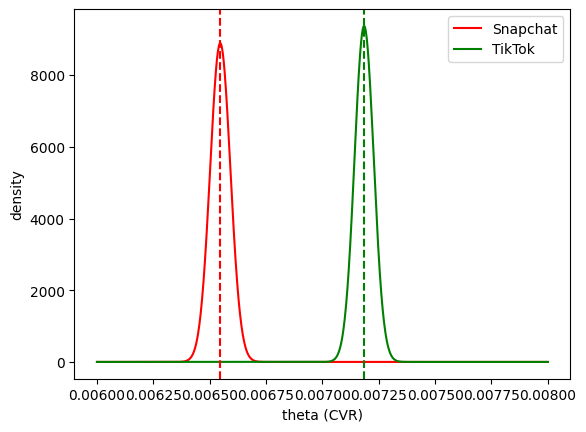

Snapchat: mean=0.006547, var=2.014e-09, std=0.000045
TikTok  : mean=0.007185, var=1.812e-09, std=0.000043
P(θ_TikTok > θ_Snapchat) = 1


In [6]:
a_snapchat, b_snapchat = 21149, 3209117
a_tiktok,   b_tiktok   = 28282, 3907837

x = np.linspace(0.0060, 0.0080, 1000)

y_snap   = beta.pdf(x, a_snapchat, b_snapchat)
y_tiktok = beta.pdf(x, a_tiktok,   b_tiktok)

plt.plot(x, y_snap,   label='Snapchat', color='red')
plt.plot(x, y_tiktok, label='TikTok',   color='green')

plt.axvline(a_snapchat/(a_snapchat+b_snapchat), color='red',   ls='--')
plt.axvline(a_tiktok/(a_tiktok+b_tiktok),       color='green', ls='--')

plt.xlabel('theta (CVR)')
plt.ylabel('density')
plt.legend()
plt.show()

# E = a/(a+b)
mean_snap   = a_snapchat / (a_snapchat + b_snapchat)
mean_tiktok = a_tiktok   / (a_tiktok   + b_tiktok)

# Var = a*b / ((a+b)^2 * (a+b+1))
var_snap   = (a_snapchat * b_snapchat) / ((a_snapchat + b_snapchat)**2 * (a_snapchat + b_snapchat + 1))
var_tiktok = (a_tiktok   * b_tiktok)   / ((a_tiktok   + b_tiktok)**2   * (a_tiktok   + b_tiktok   + 1))

print(f'Snapchat: mean={mean_snap:.6f}, var={var_snap:.3e}, std={var_snap**0.5:.6f}')
print(f'TikTok  : mean={mean_tiktok:.6f}, var={var_tiktok:.3e}, std={var_tiktok**0.5:.6f}')
print('P(θ_TikTok > θ_Snapchat) = 1')

### Introducing Monte Carlo Simulation

In the previous section, we used the Beta-Binomial conjugate model to obtain the posterior distributions of the CVR for different advertising platforms.

Now, let's introduce Monte Carlo simulation. We draw random samples of θ from the posterior Beta distribution and visualize them using a histogram. As the sample size increases, the histogram gradually converges to the true Beta posterior.

This example demonstrates the core idea of Monte Carlo methods. Although the posterior distribution is analytically available in this Beta-Binomial model, we can also represent the same distribution using a large number of random samples. Again, as the sample size increases, the histogram of the sampled values approaches the true posterior distribution.

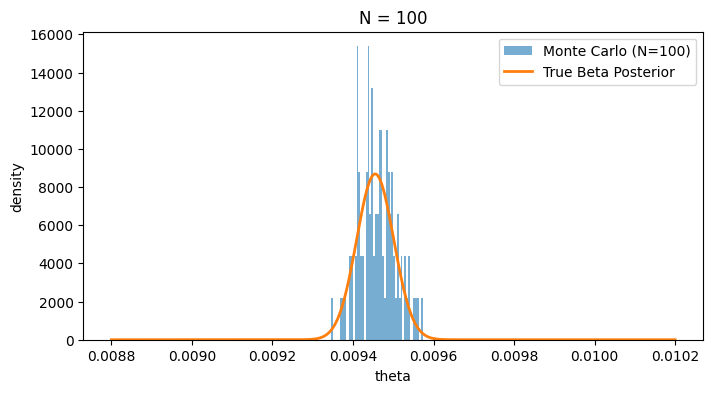

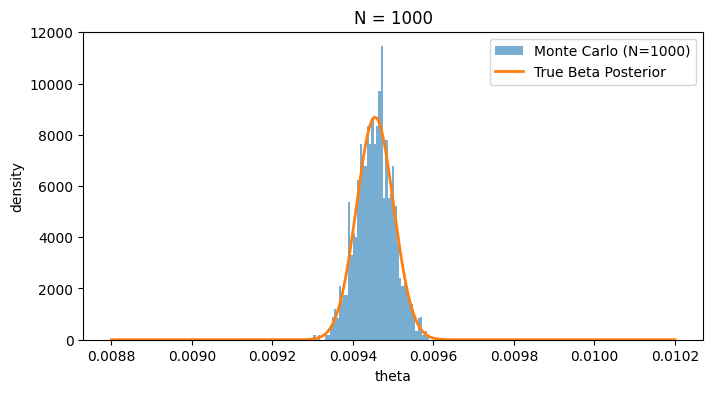

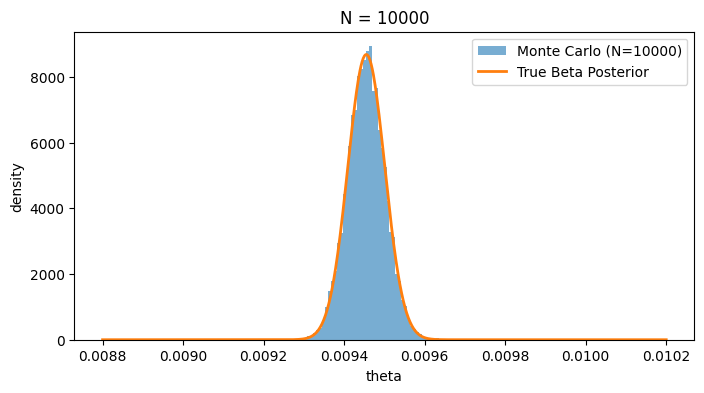

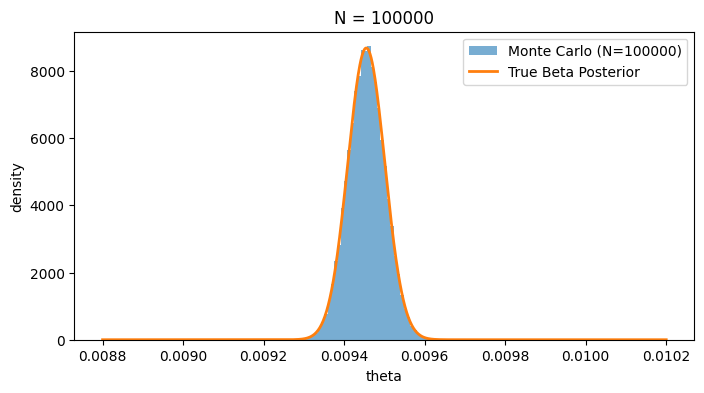

In [7]:

a = 41979
b = 4397788

# 真正的 Beta posterior
x = np.linspace(0.0088, 0.0102, 1000)
y = beta.pdf(x, a, b)

for N in [100, 1000, 10000, 100000]:

    samples = beta.rvs(a, b, size=N)

    plt.figure(figsize=(8,4))

    # Monte Carlo histogram
    plt.hist(
        samples,
        bins=50,
        density=True,
        alpha=0.6,
        label=f'Monte Carlo (N={N})'
    )

    # 真正的 Beta 曲线
    plt.plot(
        x,
        y,
        linewidth=2,
        label='True Beta Posterior'
    )

    plt.title(f'N = {N}')
    plt.xlabel('theta')
    plt.ylabel('density')
    plt.legend()

    plt.show()